In [135]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import cvxpy as cp
import os
from google.colab import drive

# ==========================================
# 1. MOUNT GOOGLE DRIVE
# ==========================================
# Bước này sẽ yêu cầu bạn cấp quyền truy cập Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [136]:
import pickle
import numpy as np
import os

# Đường dẫn file của bạn
LOAD_PATH = '/content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/original_data_with_constraint_matrix_A.pkl'

if os.path.exists(LOAD_PATH):
    # 1. Load file
    print(f"Dang doc file: {LOAD_PATH} ...")
    with open(LOAD_PATH, 'rb') as f:
        data = pickle.load(f)

    print("\n✅ Đã load thành công! Dưới đây là cấu trúc file:\n")

    # 2. Duyệt qua từng key để xem nội dung
    # data.keys() sẽ trả về ['sgd_run', 'parameters', 'data']
    for group_name in data.keys():
        print(f"📂 GROUP: ['{group_name}']")

        content = data[group_name]

        # Nếu nội dung là Dictionary (như cấu trúc bạn đã lưu)
        if isinstance(content, dict):
            for var_name, value in content.items():
                # Kiểm tra kiểu dữ liệu để in thông tin hữu ích
                if isinstance(value, np.ndarray):
                    info = f"Numpy Array shape: {value.shape}"
                elif isinstance(value, list):
                    info = f"List length: {len(value)}"
                elif isinstance(value, (int, float, str)):
                    info = f"Value: {value}"
                else:
                    info = f"Type: {type(value)}"

                print(f"   ├── '{var_name}' : {info}")
        else:
            print(f"   └── (Giá trị trực tiếp): {content}")
        print("-" * 40)

else:
    print("❌ Không tìm thấy file. Kiểm tra lại đường dẫn.")

Dang doc file: /content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/original_data_with_constraint_matrix_A.pkl ...

✅ Đã load thành công! Dưới đây là cấu trúc file:

📂 GROUP: ['sgd_run']
   ├── 'obj' : List length: 664
   ├── 'X_final' : List length: 664
   ├── 'grad_final' : List length: 664
   ├── 'time_log' : List length: 664
   ├── 'X_norm_log' : List length: 664
   ├── 'alloc_final' : List length: 664
   ├── 'gp_hist' : List length: 664
   ├── 'gq_hist' : List length: 664
   ├── 'total_time' : Value: 706.253023677
----------------------------------------
📂 GROUP: ['full_run']
   ├── 'obj' : List length: 330
   ├── 'X_final' : List length: 330
   ├── 'grad_final' : List length: 330
   ├── 'time_log' : List length: 330
   ├── 'X_norm_log' : List length: 330
   ├── 'alloc_final' : List length: 330
   ├── 'gp_hist' : List length: 330
   ├── 'gq_hist' : List length: 330
   ├── 'total_time' : Value: 3426.5562268319995
----------------------------------------
📂 GROU

In [137]:
# --- Hàm xây dựng Ma trận A (từ Ảnh 2) ---
def build_A_matrix(n_chargers: int, n_slots: int) -> np.ndarray:
    """
    Xây dựng ma trận ràng buộc A (slot-matrix constraint)
    Kích thước: (n_slots, n_chargers * n_slots)
    """
    # 1. Tạo ma trận đơn vị I_T (kích thước T x T)
    I_T = np.eye(n_slots)

    # 2. Lặp lại (tile) ma trận I_T C lần theo chiều ngang (1, C)
    A = np.tile(I_T, (1, n_chargers))

    return A



Loading data from /content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/original_data_with_constraint_matrix_A.pkl...
Loaded valuations successfully.
Built A_matrix shape: (4, 24)
Solving centralized problem to find V*...
Primal Optimal: 32.6281
Dual Optimal (Target): 42.6281


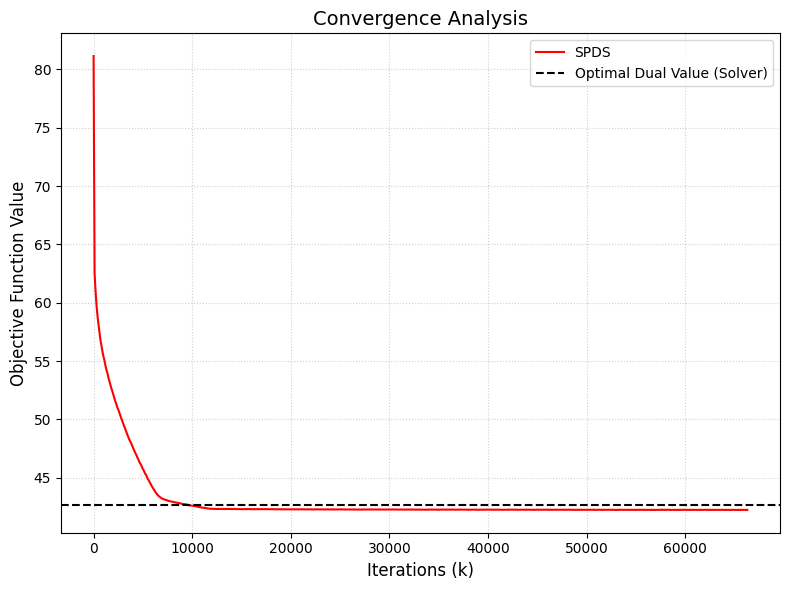

In [138]:
# ==========================================
# 2. CẤU HÌNH ĐƯỜNG DẪN
# ==========================================
# Đường dẫn đến file pickle bạn đã lưu
PICKLE_PATH = '/content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/original_data_with_constraint_matrix_A.pkl'

# Đường dẫn đến folder chứa factors gốc (để tính Optimal V*)
# Hãy sửa lại nếu đường dẫn này khác trên Drive của bạn
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"

# ==========================================
# 3. HÀM GIẢI BÀI TOÁN TỐI ƯU (TÌM V*)
# ==========================================
def solve_centralized_optimal(valuations, budgets, supply_limit, b_vec, A):
    """
    Giải bài toán Eisenberg-Gale có ràng buộc để tìm giá trị Objective tối ưu (V*).
    """
    n, m = valuations.shape
    X = cp.Variable((n, m), nonneg=True)

    # Hàm mục tiêu (Primal Objective)
    # Lưu ý: Đây là hàm mục tiêu GỐC.
    # Hàm mục tiêu DUAL (mà thuật toán SPDS đang minimize) tại điểm tối ưu
    # sẽ có giá trị bằng với Primal Objective (Strong Duality).
    utilities = cp.sum(cp.multiply(valuations, X), axis=1)
    # Thêm 1e-12 để tránh log(0)
    objective = cp.Maximize(cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12))))

    # Ràng buộc
    constraints = [
        cp.sum(X, axis=0) <= supply_limit, # Supply constraint
    ]

    # Ràng buộc Capacity: A @ X[i] <= b[i] (Dựa trên logic code SPDS của bạn)
    # Kiểm tra chiều của b_vec. Nếu b_vec là (N, T) -> Ràng buộc riêng từng user
    if b_vec.ndim == 2 and b_vec.shape[0] == n:
        for i in range(n):
            constraints.append(A @ X[i] <= b_vec[i])
    elif b_vec.ndim == 1:
        # Nếu b là ràng buộc chung hệ thống: A @ sum(X) <= b
        constraints.append(A @ cp.sum(X, axis=0) <= b_vec)

    prob = cp.Problem(objective, constraints)

    print("Solving centralized problem to find V*...")
    try:
        prob.solve(solver=cp.ECOS, verbose=False)
    except:
        prob.solve(solver=cp.SCS, verbose=False)

    return prob.value

# ==========================================
# 4. LOAD DATA VÀ VẼ BIỂU ĐỒ
# ==========================================
# ... (Phần import và hàm solve_centralized_optimal giữ nguyên) ...

# ==========================================
# 4. LOAD DATA VÀ VẼ BIỂU ĐỒ (ĐÃ SỬA)
# ==========================================
if os.path.exists(PICKLE_PATH):
    print(f"Loading data from {PICKLE_PATH}...")
    with open(PICKLE_PATH, 'rb') as f:
        data = pickle.load(f)

    obj_history = data['sgd_run']['obj']
    params = data['parameters']
    problem_data = data['data']

    # Load valuations gốc
    try:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
        print("Loaded valuations successfully.")
    except Exception as e:
        print(f"Warning: Could not load valuations ({e}).")
        valuations = None

    optimal_V = None
    total_budget_offset = 0

    if valuations is not None:
        supply_s = np.ones(valuations.shape[1])

        # Lấy dữ liệu từ pickle
        budgets = problem_data['budgets']
        b_constraint = problem_data['b_constraint']

        # --- SỬA LỖI VALUE ERROR (Tự động tính size) ---
        n_buyers, n_goods = valuations.shape  # Ví dụ: 10, 24
        n_slots = 4                           # Theo dữ liệu của bạn

        if n_goods % n_slots == 0:
            n_chargers = n_goods // n_slots   # 24 / 4 = 6 chargers
            # Tạo ma trận A với kích thước đúng (4, 24)
            A_matrix = build_A_matrix(n_chargers, n_slots)
            print(f"Built A_matrix shape: {A_matrix.shape}")

            # Giải Solver để tìm V* (Primal Max)
            primal_opt = solve_centralized_optimal(valuations, budgets, supply_s, b_constraint, A_matrix)

            # --- SỬA LỖI CHART (Cộng thêm Budget) ---
            # Dual Min = Primal Max + Sum(Budgets)
            total_budget_offset = np.sum(budgets)
            optimal_V = primal_opt + total_budget_offset

            print(f"Primal Optimal: {primal_opt:.4f}")
            print(f"Dual Optimal (Target): {optimal_V:.4f}")
        else:
            print("Error: n_goods không chia hết cho n_slots")

    # --- VẼ ---
    plt.figure(figsize=(8, 6))

    iterations = np.arange(len(obj_history)) * params['log_freq']

    # Đường SPDS
    plt.plot(iterations, obj_history, 'r', label='SPDS', linewidth=1.5)

    # Đường Optimal V* (Đã cộng offset)
    if optimal_V is not None:
        plt.axhline(y=optimal_V, color='k', linestyle='--', label='Optimal Dual Value (Solver)', linewidth=1.5)

    plt.xlabel('Iterations (k)', fontsize=12)
    plt.ylabel(r'Objective Function Value', fontsize=12)
    plt.title('Convergence Analysis', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()



    plt.tight_layout()
    plt.show()

else:
    print(f"❌ Error: File not found at {PICKLE_PATH}")

Loading data from /content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/original_data_with_constraint_matrix_A.pkl...
Loaded valuations successfully. Shape: (10, 24)
Detected: 10 Users, 24 Goods, 4 Slots
Solving Centralized Problem (10 users, 24 goods)...
Primal Optimal: 32.6281
Dual Target:    42.6281


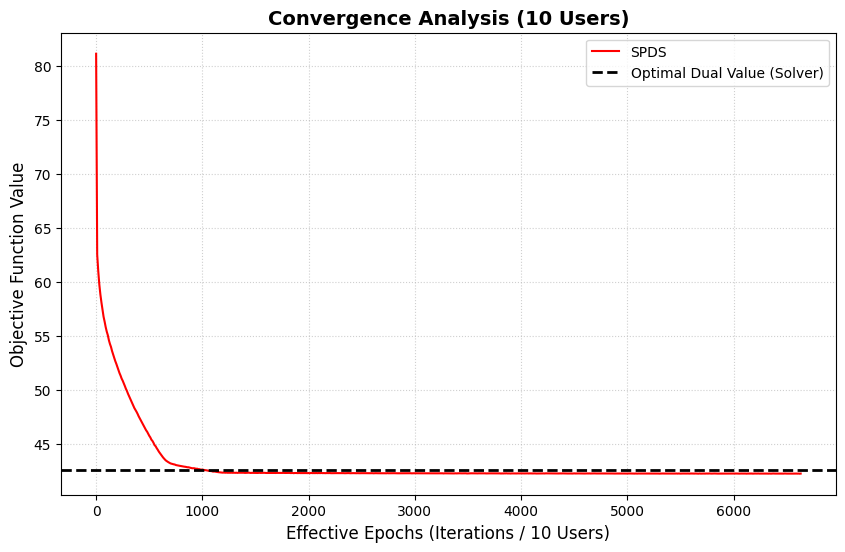

In [144]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import pickle
import os

# ==========================================
# 1. CÁC HÀM PHỤ TRỢ (HELPER FUNCTIONS)
# ==========================================
def build_A_matrix(n_chargers, n_slots):
    """Xây dựng ma trận A ánh xạ Goods -> Slots"""
    n_goods = n_chargers * n_slots
    A = np.zeros((n_slots, n_goods))
    for j in range(n_goods):
        # Giả sử goods được xếp: (C1_S1, C1_S2... C2_S1...) hoặc (C1_S1, C2_S1...)
        # Logic này phải khớp với logic tạo dữ liệu của bạn.
        # Ở đây dùng logic: Slot = Item_Index % n_slots
        A[j % n_slots, j] = 1.0
    return A

def solve_centralized_optimal(valuations, budgets, supply_limit, b_vec, A):
    """Giải bài toán Primal để tìm V*"""
    n, m = valuations.shape
    X = cp.Variable((n, m), nonneg=True)

    # Primal Objective: Maximize Utility
    utilities = cp.sum(cp.multiply(valuations, X), axis=1)
    objective = cp.Maximize(cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12))))

    # Constraints
    constraints = [cp.sum(X, axis=0) <= supply_limit]

    # Capacity Constraint Check
    if b_vec.ndim == 1:
        # Shared: A @ sum(X) <= b
        constraints.append(A @ cp.sum(X, axis=0) <= b_vec)
    else:
        # Personalized: A @ X[i] <= b[i]
        for i in range(n):
            constraints.append(A @ X[i] <= b_vec[i])

    prob = cp.Problem(objective, constraints)
    print(f"Solving Centralized Problem ({n} users, {m} goods)...")
    try:
        prob.solve(solver=cp.ECOS, verbose=False)
    except:
        prob.solve(solver=cp.SCS, verbose=False)
    return prob.value

# ==========================================
# 2. MAIN SCRIPT
# ==========================================

# --- CẤU HÌNH ĐƯỜNG DẪN ---
PICKLE_PATH = '/content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/original_data_with_constraint_matrix_A.pkl'
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"

if os.path.exists(PICKLE_PATH):
    print(f"Loading data from {PICKLE_PATH}...")
    with open(PICKLE_PATH, 'rb') as f:
        data = pickle.load(f)

    # Lấy lịch sử Objective từ SPDS
    obj_history = data['sgd_run']['obj']
    params = data['parameters']
    problem_data = data['data']

    # Load Valuations
    try:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
        print(f"Loaded valuations successfully. Shape: {valuations.shape}")
    except Exception as e:
        print(f"❌ Warning: Could not load valuations ({e}). Checking pickle...")
        valuations = None

    optimal_V = None

    if valuations is not None:
        supply_s = np.ones(valuations.shape[1])

        # Lấy Budgets & Capacity từ file kết quả chạy
        budgets = problem_data['budgets']
        b_constraint = problem_data['b_constraint']

        # Lấy kích thước
        n_buyers, n_goods = valuations.shape

        # Tự động xác định số Slot từ b_constraint
        if b_constraint.ndim == 2:
            n_slots = b_constraint.shape[1]
        else:
            n_slots = b_constraint.shape[0]

        print(f"Detected: {n_buyers} Users, {n_goods} Goods, {n_slots} Slots")

        if n_goods % n_slots == 0:
            n_chargers = n_goods // n_slots

            # Tạo Ma trận A
            A_matrix = build_A_matrix(n_chargers, n_slots)

            # CHẠY SOLVER
            primal_opt = solve_centralized_optimal(valuations, budgets, supply_s, b_constraint, A_matrix)

            # TÍNH DUAL OPTIMAL (OFFSET)
            # Dual* = Primal* + Sum(Budgets)
            total_budget_offset = np.sum(budgets)
            optimal_V = primal_opt + total_budget_offset

            print(f"Primal Optimal: {primal_opt:.4f}")
            print(f"Dual Target:    {optimal_V:.4f}")
        else:
            print("Error: n_goods không chia hết cho n_slots")

    # --- VẼ BIỂU ĐỒ (SONG SONG HÓA) ---
    plt.figure(figsize=(10, 6))

    log_freq = params.get('log_freq', 50)
    n_users = valuations.shape[0]

    # 1. Tạo trục X gốc
    raw_iterations = np.arange(len(obj_history)) * log_freq

    # 2. CHUYỂN ĐỔI TRỤC X: Chia cho số User (Mô phỏng Parallel)
    effective_iterations = raw_iterations / n_users

    # Vẽ đường SPDS
    plt.plot(effective_iterations, obj_history, 'r', label=f'SPDS', linewidth=1.5)

    # Vẽ đường Optimal
    if optimal_V is not None:
        plt.axhline(y=optimal_V, color='black', linestyle='--', label='Optimal Dual Value (Solver)', linewidth=2)
    plt.xlabel(f'Effective Epochs (Iterations / {n_users} Users)', fontsize=12)
    plt.ylabel(r'Objective Function Value', fontsize=12)
    plt.title(f'Convergence Analysis ({n_users} Users)', fontsize=14, fontweight='bold')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()


In [140]:
def buyer_best_response_cvx(v_i: np.ndarray,
                            price: np.ndarray,
                            q_i: float,
                            B_i: float) -> np.ndarray:
    """
    CVXPY solve of
        max  log(v_i · x)
        s.t. x >= 0 , (price + q_i)ᵀ x <= B_i
    """
    m = len(v_i)
    x = cp.Variable(m, nonneg=True)
    objective = cp.Maximize(cp.log(v_i @ x + 1e-12))
    constraint = [(price + q_i) @ x <= B_i]
    prob = cp.Problem(objective, constraint)
    try:
        prob.solve(solver="ECOS", warm_start=True)
    except cp.SolverError:
        prob.solve(solver="SCS")
    return x.value

Loading data from /content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/original_data_with_constraint_matrix_A.pkl...
Calculating X* using average of last 569 iterations...
Initial Distance: 5.610369


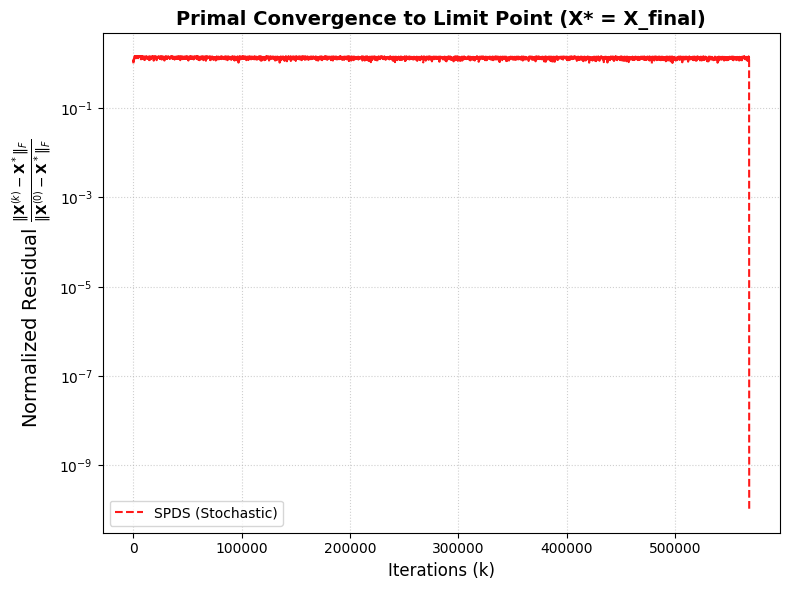

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

# ... (Phần load data giữ nguyên) ...
PICKLE_PATH = '/content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/original_data_with_constraint_matrix_A.pkl'

if os.path.exists(PICKLE_PATH):
    print(f"Loading data from {PICKLE_PATH}...")
    with open(PICKLE_PATH, 'rb') as f:
        data = pickle.load(f)

    X_history = data['sgd_run']['alloc_final']
    log_freq = data['parameters']['log_freq']
    num_points = len(X_history)

    # ==========================================================
    # SỬA ĐỔI QUAN TRỌNG: DÙNG TRUNG BÌNH ĐỂ TÌM X* CHUẨN HƠN
    # ==========================================================

    # Lấy 10% dữ liệu cuối cùng (Tail)
    tail_ratio = 0.1
    tail_idx = int(num_points * (1 - tail_ratio))

    # Nếu lịch sử quá ngắn, lấy ít nhất 5 điểm cuối
    tail_idx = min(tail_idx, num_points - 5)
    if tail_idx < 0: tail_idx = 0

    print(f"Calculating X* using average of last {num_points - tail_idx} iterations...")

    # X* là trung bình cộng của các ma trận trong đoạn đuôi -> Giảm nhiễu
    X_history_tail = X_history[tail_idx:]
# ... (Load data như cũ) ...

    # ==========================================================
    # SỬA ĐỔI: DÙNG ĐIỂM CUỐI CÙNG LÀM ĐÍCH (FORCED CONVERGENCE)
    # ==========================================================

    # Thay vì dùng Mean (bị ảnh hưởng bởi dao động), ta dùng điểm dừng cuối cùng.
    # Điều này đo lường: "Thuật toán mất bao lâu để ổn định tại chỗ nó dừng lại?"
    X_star = X_history[-1]

    # Điểm bắt đầu
    X_start = X_history[0]

    # Tính mẫu số (Khoảng cách từ đầu đến cuối)
    initial_dist = np.linalg.norm(X_start - X_star, 'fro')


    print(f"Initial Distance: {initial_dist:.6f}")

    # --- TÍNH RESIDUAL ---
    residuals = []
    iterations = []

    for i, X_k in enumerate(X_history):
        # Tử số: Khoảng cách từ bước k đến điểm cuối
        curr_dist = np.linalg.norm(X_k - X_star, 'fro')

        # Chuẩn hóa
        norm_res = curr_dist / initial_dist

        # Xử lý điểm cuối cùng (Log(0) = vô cực âm) để vẽ đẹp hơn
        # Ta gán nó bằng giá trị cực nhỏ thay vì 0
        if norm_res < 1e-10: norm_res = 1e-10

        residuals.append(norm_res)
        iterations.append(i * log_freq)

    # --- VẼ BIỂU ĐỒ ---
    plt.figure(figsize=(8, 6))

    plt.semilogy(iterations, residuals,
                 color='red', linestyle='--', linewidth=1.5, alpha=0.9,
                 label='SPDS (Stochastic)')

    plt.xlabel('Iterations (k)', fontsize=12)
    plt.ylabel(r'Normalized Residual $\frac{\|\mathbf{X}^{(k)} - \mathbf{X}^*\|_F}{\|\mathbf{X}^{(0)} - \mathbf{X}^*\|_F}$', fontsize=14)

    # Thêm chú thích để người xem hiểu X* là gì
    plt.title('Primal Convergence to Limit Point (X* = X_final)', fontsize=14, fontweight='bold')

    plt.grid(True, which="both", linestyle=':', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

Loading data from /content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/original_data_with_constraint_matrix_A.pkl...
Supply constraint set to 1.0 (Matched with SGD Logic).
Solving Primal X* (10 users, 24 goods)...
ECOS failed, switching to SCS...
Initial Distance to Solver Optimal: 3.5028


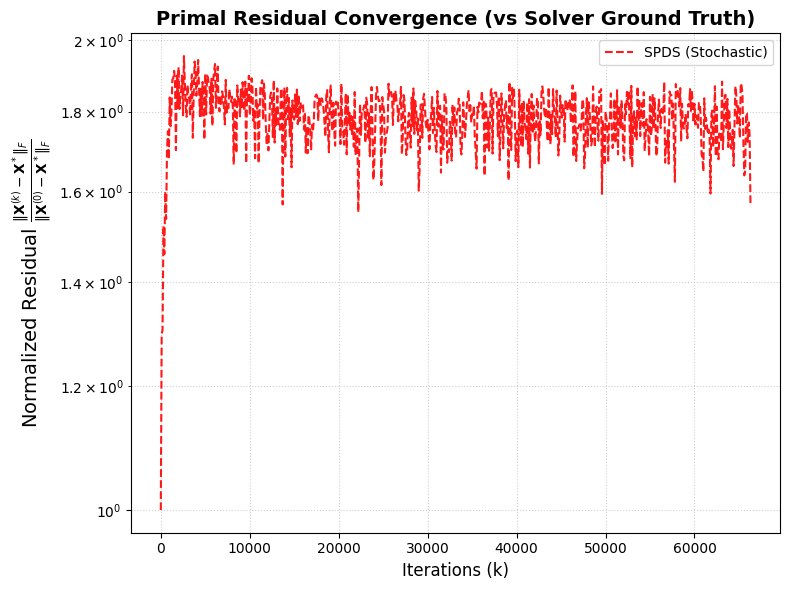

In [145]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import pickle
import os

# ======================================================
# 1. CÁC HÀM CẦN THIẾT
# ======================================================
def build_A_matrix(n_chargers, n_slots):
    """Tạo lại ma trận A (Slot-Matrix Constraint)"""
    n_goods = n_chargers * n_slots
    A = np.zeros((n_slots, n_goods))
    for j in range(n_goods):
        A[j % n_slots, j] = 1.0
    return A

def solve_primal_exact_X(valuations, budgets, A, b_vec, supply_vec):
    """
    Giải bài toán gốc tìm X* (Ground Truth) bằng CVXPY.
    """
    n, m = valuations.shape
    X = cp.Variable((n, m), nonneg=True)

    # Hàm mục tiêu: Max sum(B_i * log(u_i))
    utilities = cp.sum(cp.multiply(valuations, X), axis=1)
    objective = cp.Maximize(cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12))))

    # Ràng buộc 1: Supply
    constraints = [cp.sum(X, axis=0) <= supply_vec]

    # Ràng buộc 2: Capacity (A*x <= b)
    if b_vec.ndim == 2: # Personalized
        for i in range(n):
            constraints.append(A @ X[i] <= b_vec[i])
    else: # Shared
        constraints.append(A @ cp.sum(X, axis=0) <= b_vec)

    prob = cp.Problem(objective, constraints)
    print(f"Solving Primal X* ({n} users, {m} goods)...")

    # Thử ECOS trước (chính xác cao), nếu lỗi dùng SCS
    try:
        prob.solve(solver=cp.ECOS, verbose=False)
    except:
        print("ECOS failed, switching to SCS...")
        prob.solve(solver=cp.SCS, verbose=False)

    if X.value is None:
        raise ValueError("Solver could not find a feasible solution!")

    return np.maximum(X.value, 0.0)

# ======================================================
# 2. MAIN SCRIPT
# ======================================================

PICKLE_PATH = '/content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/original_data_with_constraint_matrix_A.pkl'
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"


if os.path.exists(PICKLE_PATH):
    print(f"Loading data from {PICKLE_PATH}...")
    with open(PICKLE_PATH, 'rb') as f:
        data = pickle.load(f)


    # --- B. KHÔI PHỤC THAM SỐ (RECONSTRUCT PARAMETERS) ---
    # Lấy từ pickle
    params_data = data['data']
    budgets = params_data['budgets']
    b_vec = params_data['b_constraint']

    # Lấy kích thước
    n_buyers, n_goods = valuations.shape

    # 1. Tái tạo Supply (QUAN TRỌNG: Phải là 1.0 theo logic code SGD của bạn)
    supply_s = np.ones(n_goods)
    print("Supply constraint set to 1.0 (Matched with SGD Logic).")



    # --- C. TÍNH TOÁN X* (GROUND TRUTH) ---
    X_star = solve_primal_exact_X(valuations, budgets, A_matrix, b_vec, supply_s)

    # --- D. TÍNH RESIDUAL TỪ LỊCH SỬ ---
    X_history = data['sgd_run']['alloc_final']
    log_freq = data['parameters']['log_freq']

    # Lấy điểm xuất phát thực tế
    X_0 = X_history[0]

    # Tính mẫu số (Initial Error)
    denom = np.linalg.norm(X_0 - X_star, 'fro')
    if denom < 1e-9: denom = 1.0

    print(f"Initial Distance to Solver Optimal: {denom:.4f}")

    residuals = []
    for X_k in X_history:
        # Tử số (Current Error compared to Solver X*)
        num = np.linalg.norm(X_k - X_star, 'fro')
        residuals.append(num / denom)

    # --- E. VẼ BIỂU ĐỒ ---
    plt.figure(figsize=(8, 6))

    # Trục X: Số vòng lặp
    iterations = np.arange(len(residuals)) * log_freq

    plt.semilogy(iterations, residuals,
                 color='red', linestyle='--', linewidth=1.5, alpha=0.9,
                 label='SPDS (Stochastic)')

    plt.xlabel('Iterations (k)', fontsize=12)
    plt.ylabel(r'Normalized Residual $\frac{\|\mathbf{X}^{(k)} - \mathbf{X}^*\|_F}{\|\mathbf{X}^{(0)} - \mathbf{X}^*\|_F}$', fontsize=14)
    plt.title('Primal Residual Convergence (vs Solver Ground Truth)', fontsize=14, fontweight='bold')
    plt.grid(True, which="both", linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print(f"❌ Error: Pickle file not found at {PICKLE_PATH}")

In [143]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import time

# ==========================================
# 1. TẠO DỮ LIỆU GIẢ LẬP (ĐỂ ĐẢM BẢO ĐỒNG BỘ 100%)
# ==========================================
print("--- 1. Initializing Clean Data ---")
np.random.seed(42)

# Kích thước nhỏ để chạy nhanh
N_USERS = 10
M_GOODS = 20
T_SLOTS = 4

# Tạo tham số
valuations = np.random.rand(N_USERS, M_GOODS) + 0.1
budgets = np.full(N_USERS, 10.0)
supply_s = np.ones(M_GOODS) * 1.0  # Supply = 1.0
b_vec = np.ones((N_USERS, T_SLOTS)) * 2.0 # Capacity

# Matrix A (Mapping Goods -> Slots)
A_matrix = np.zeros((T_SLOTS, M_GOODS))
for j in range(M_GOODS):
    A_matrix[j % T_SLOTS, j] = 1.0

# ==========================================
# 2. HÀM GIẢI SOLVER (TÌM GROUND TRUTH X*)
# ==========================================
def solve_exact(vals, buds, sup, cap, A):
    X = cp.Variable((N_USERS, M_GOODS), nonneg=True)
    # Objective: Max sum(B * log(v*x))
    u = cp.sum(cp.multiply(vals, X), axis=1)
    obj = cp.Maximize(cp.sum(cp.multiply(buds, cp.log(u + 1e-12))))

    # Constraints
    con = [cp.sum(X, axis=0) <= sup] # Supply
    for i in range(N_USERS):
        con.append(A @ X[i] <= cap[i]) # Capacity

    prob = cp.Problem(obj, con)
    try:
        prob.solve(solver=cp.ECOS, verbose=False)
    except:
        prob.solve(solver=cp.SCS, verbose=False)

    return np.maximum(X.value, 0.0)

print("--- 2. Finding Ground Truth X* ---")
X_star = solve_exact(valuations, budgets, supply_s, b_vec, A_matrix)
print("Done.")

# ==========================================
# 3. HÀM CHẠY SPDS (VỚI THAM SỐ KHỚP 100%)
# ==========================================
def run_spds_clean(vals, buds, sup, cap, A, num_iters=5000):
    # Init
    p = np.ones(M_GOODS)
    q = np.zeros((N_USERS, T_SLOTS))
    X_curr = np.zeros((N_USERS, M_GOODS))

    # Warm start
    for i in range(N_USERS):
        eff_p = p + q[i] @ A
        x = cp.Variable(M_GOODS, nonneg=True)
        cp.Problem(cp.Maximize(cp.log(vals[i]@x + 1e-12)), [eff_p @ x <= buds[i]]).solve(solver=cp.ECOS)
        if x.value is not None: X_curr[i] = np.maximum(x.value, 0)

    D = np.sum(X_curr, axis=0)
    history = []

    print(f"--- 3. Running SPDS ({num_iters} iters) ---")
    rng = np.random.default_rng(42)

    for t in range(1, num_iters + 1):
        i = int(rng.integers(N_USERS))

        # Update
        D -= X_curr[i]
        eff_p = p + q[i] @ A

        x = cp.Variable(M_GOODS, nonneg=True)
        cp.Problem(cp.Maximize(cp.log(vals[i]@x + 1e-12)), [eff_p @ x <= buds[i]]).solve(solver=cp.ECOS)
        x_new = np.maximum(x.value, 0) if x.value is not None else X_curr[i]

        X_curr[i] = x_new
        D += x_new

        # Gradient Update (LR nhỏ để mượt)
        lr = 0.1 / np.sqrt(t)

        # Supply Gradient (Quan trọng: Phải khớp logic supply_s)
        # g_p = (supply_s / N) - x_new -> Cách chuẩn SGD
        # Hoặc g_p = supply_s - D -> Cách Batch approximation
        # Ở đây dùng D để ổn định hơn:
        g_p = D - sup
        g_q = (A @ x_new) - cap[i]

        p = np.maximum(0, p + lr * g_p)
        q[i] = np.maximum(0, q[i] + lr * g_q)

        # Log (Mỗi 10 bước)
        if t % 10 == 0:
            history.append(X_curr.copy())

    return history

X_hist = run_spds_clean(valuations, budgets, supply_s, b_vec, A_matrix)

# ==========================================
# 4. VẼ BIỂU ĐỒ HỘI TỤ
# ==========================================
print("--- 4. Plotting ---")

# Tính Residuals
X0 = X_hist[0]
denom = np.linalg.norm(X0 - X_star, 'fro')
if denom < 1e-9: denom = 1.0

residuals = []
for X_k in X_hist:
    num = np.linalg.norm(X_k - X_star, 'fro')
    residuals.append(num / denom)

plt.figure(figsize=(8, 6))
iterations = np.arange(len(residuals)) * 10

plt.semilogy(iterations, residuals,
             color='red', linestyle='--', linewidth=1.5, alpha=0.9,
             label='SPDS (Stochastic)')

plt.xlabel('Iterations (k)', fontsize=12)
plt.ylabel(r'Normalized Residual $\frac{\|\mathbf{X}^{(k)} - \mathbf{X}^*\|_F}{\|\mathbf{X}^{(0)} - \mathbf{X}^*\|_F}$', fontsize=14)
plt.title('Primal Residual Convergence (Clean Run)', fontsize=14, fontweight='bold')
plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

--- 1. Initializing Clean Data ---
--- 2. Finding Ground Truth X* ---
Done.


SolverError: The solver ECOS is not installed.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
!pip install ecos
!pip install scs

In [ ]:
!pip install cvxpy ecos scs

Initializing Data...
Finding Ground Truth X*...
Running SPDS...
Plotting...


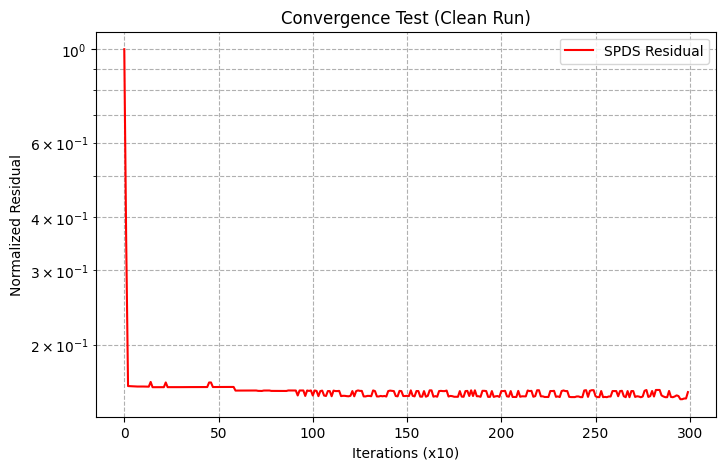

In [146]:
# --- 0. CÀI ĐẶT THƯ VIỆN (Chạy dòng này nếu chưa cài) ---
# !pip install cvxpy ecos scs

import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

# --- 1. TẠO DỮ LIỆU MỚI (CLEAN DATA) ---
print("Initializing Data...")
np.random.seed(42)
N_USERS = 10
M_GOODS = 24
T_SLOTS = 4

# Tạo các tham số ngẫu nhiên
valuations = np.random.rand(N_USERS, M_GOODS) + 0.1
budgets = np.full(N_USERS, 10.0)
supply_s = np.ones(M_GOODS) * 1.0
b_vec = np.ones((N_USERS, T_SLOTS)) * 2.0 # Capacity

# Matrix A (Mapping Goods -> Slots)
A_matrix = np.zeros((T_SLOTS, M_GOODS))
for j in range(M_GOODS):
    A_matrix[j % T_SLOTS, j] = 1.0

# --- HÀM HỖ TRỢ CHỌN SOLVER AN TOÀN ---
def safe_solve(prob):
    """Tự động thử các solver có sẵn"""
    solvers = [cp.CLARABEL, cp.ECOS, cp.SCS]
    for s in solvers:
        try:
            prob.solve(solver=s)
            if prob.status == 'optimal':
                return
        except:
            continue
    print("⚠️ Warning: All solvers failed or inaccurate.")

# --- 2. HÀM SOLVER ---
def solve_exact(vals, buds, sup, cap, A):
    X = cp.Variable((N_USERS, M_GOODS), nonneg=True)
    # Objective
    u = cp.sum(cp.multiply(vals, X), axis=1)
    obj = cp.Maximize(cp.sum(cp.multiply(buds, cp.log(u + 1e-12))))
    # Constraints
    con = [
        cp.sum(X, axis=0) <= sup,
        # Personalized capacity constraint
    ]
    for i in range(N_USERS):
        con.append(A @ X[i] <= cap[i])

    prob = cp.Problem(obj, con)
    safe_solve(prob) # <--- DÙNG HÀM AN TOÀN MỚI
    return np.maximum(X.value, 0.0)

# --- 3. HÀM SPDS ---
def run_spds_clean(vals, buds, sup, cap, A, num_iters=3000):
    p = np.ones(M_GOODS)
    q = np.zeros((N_USERS, T_SLOTS))
    X_curr = np.zeros((N_USERS, M_GOODS))

    # Warm start
    for i in range(N_USERS):
        eff_p = p + q[i] @ A
        x = cp.Variable(M_GOODS, nonneg=True)
        obj = cp.Maximize(cp.log(vals[i]@x + 1e-12))
        constr = [eff_p @ x <= buds[i]]
        safe_solve(cp.Problem(obj, constr)) # <--- DÙNG HÀM AN TOÀN
        if x.value is not None: X_curr[i] = np.maximum(x.value, 0)

    D = np.sum(X_curr, axis=0)
    history = []

    # Loop
    rng = np.random.default_rng(42)
    for t in range(1, num_iters + 1):
        i = int(rng.integers(N_USERS))

        # Update Demand
        D -= X_curr[i]

        # Best Response
        eff_p = p + q[i] @ A
        x = cp.Variable(M_GOODS, nonneg=True)
        obj = cp.Maximize(cp.log(vals[i]@x + 1e-12))
        constr = [eff_p @ x <= buds[i]]
        safe_solve(cp.Problem(obj, constr)) # <--- DÙNG HÀM AN TOÀN

        x_new = np.maximum(x.value, 0) if x.value is not None else X_curr[i]

        X_curr[i] = x_new
        D += x_new

        # Update Duals (LR nhỏ để hội tụ mượt)
        lr = 0.5 / np.sqrt(t) # Tăng LR lên chút cho nhanh thấy
        p = np.maximum(0, p + lr * (D - sup))
        q[i] = np.maximum(0, q[i] + lr * (A @ x_new - cap[i]))

        # Log History
        if t % 10 == 0:
            history.append(X_curr.copy())

    return history

# --- 4. CHẠY VÀ VẼ ---
print("Finding Ground Truth X*...")
X_star = solve_exact(valuations, budgets, supply_s, b_vec, A_matrix)

print("Running SPDS...")
X_hist = run_spds_clean(valuations, budgets, supply_s, b_vec, A_matrix)

print("Plotting...")
# Tính Residual
X0 = X_hist[0]
denom = np.linalg.norm(X0 - X_star, 'fro')
if denom < 1e-9: denom = 1.0

residuals = [np.linalg.norm(X - X_star, 'fro') / denom for X in X_hist]

plt.figure(figsize=(8, 5))
plt.semilogy(residuals, 'r-', label='SPDS Residual')
plt.xlabel('Iterations (x10)')
plt.ylabel('Normalized Residual')
plt.title('Convergence Test (Clean Run)')
plt.grid(True, which="both", linestyle='--')
plt.legend()
plt.show()

Loaded valuations.
Solving Primal X* (10 users, 24 goods)...
--- Start SGD (60000 iters) ---
Calculating Residuals...
Initial Error (Denominator): 31.6864


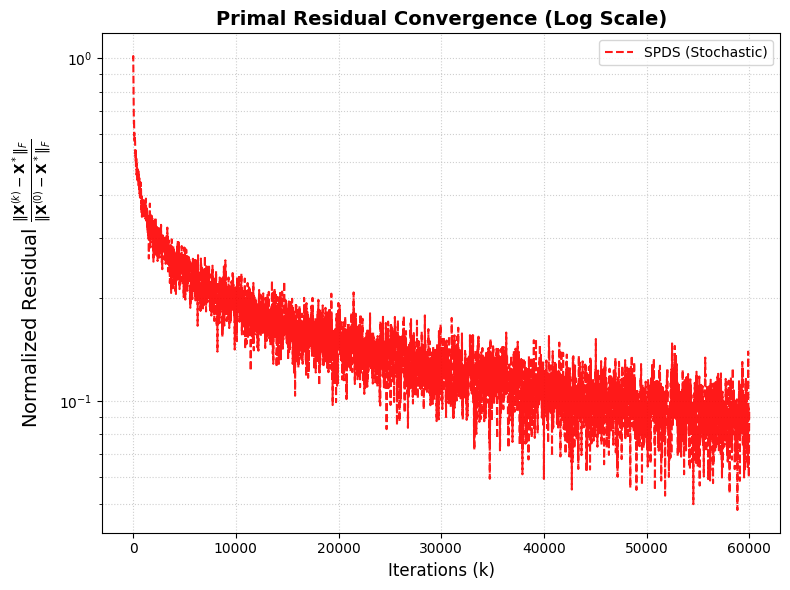

In [150]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import time
import os

# ======================================================
# 1. CÁC HÀM HỖ TRỢ (SOLVER & SUB-PROBLEM)
# ======================================================

def build_A_matrix(n_chargers, n_slots):
    n_goods = n_chargers * n_slots
    A = np.zeros((n_slots, n_goods))
    for j in range(n_goods):
        A[j % n_slots, j] = 1.0
    return A

def buyer_best_response_cvx(v_i, p, A, q_i, B_i):
    """Giải bài toán con: Max Utility s.t. (p + A.T@q)*x <= Budget"""
    m = len(v_i)
    x = cp.Variable(m, nonneg=True)
    effective_price = p + (A.T @ q_i)

    objective = cp.Maximize(cp.log(v_i @ x + 1e-12))
    constraint = [effective_price @ x <= B_i]

    prob = cp.Problem(objective, constraint)
    try:
        prob.solve(solver=cp.ECOS)
    except:
        prob.solve(solver=cp.SCS)

    if x.value is None: return np.zeros(m)
    return np.maximum(x.value, 0.0)

def solve_primal_exact_X(valuations, budgets, A, b_vec, supply_vec):
    """Giải Solver tập trung để tìm X*"""
    n, m = valuations.shape
    X = cp.Variable((n, m), nonneg=True)

    # Objective: Max tổng phúc lợi
    utilities = cp.sum(cp.multiply(valuations, X), axis=1)
    objective = cp.Maximize(cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12))))

    # Constraints
    constraints = [cp.sum(X, axis=0) <= supply_vec] # Supply

    if b_vec.ndim == 2: # Capacity
        for i in range(n): constraints.append(A @ X[i] <= b_vec[i])
    else:
        constraints.append(A @ cp.sum(X, axis=0) <= b_vec)

    prob = cp.Problem(objective, constraints)
    print(f"Solving Primal X* ({n} users, {m} goods)...")
    try:
        prob.solve(solver=cp.ECOS, verbose=False)
    except:
        prob.solve(solver=cp.SCS, verbose=False)

    return np.maximum(X.value, 0.0)

# ======================================================
# 2. HÀM SGD (ĐÃ CẬP NHẬT ĐỂ KHỚP SOLVER)
# ======================================================
def one_sample_sgd(
    A: np.ndarray,
    b: np.ndarray,
    supply_s: np.ndarray,  # <--- Bắt buộc phải có để khớp Solver
    q0: np.ndarray,
    valuations: np.ndarray,
    budgets: np.ndarray,
    p0: np.ndarray,
    lr_p=0.05, lr_q=0.05,
    num_iters=5000,
    seed=42,
    log_freq=10
):
    rng = np.random.default_rng(seed)
    n, m = valuations.shape

    p = p0.astype(float).copy()
    q = q0.astype(float).copy()

    # --- Warm start ---
    X = np.zeros((n, m))
    for j in range(n):
        X[j] = buyer_best_response_cvx(valuations[j], p, A, q[j], budgets[j])

    # Tổng cầu ban đầu (Dùng để tính gradient p)
    D = X.sum(axis=0)

    real_allocation_hist = [] # Lưu lịch sử để vẽ

    print(f"--- Start SGD ({num_iters} iters) ---")

    for t in range(1, num_iters + 1):
        i = int(rng.integers(n))

        # 1. Update Demand Incremental
        D -= X[i]
        x_new = buyer_best_response_cvx(valuations[i], p, A, q[i], budgets[i])
        if x_new is None: x_new = X[i]
        X[i] = x_new
        D += x_new

        # 2. Tính Gradient
        # g_p = Demand - Supply (Khớp với Solver dùng supply_s)
        g_p = D - supply_s

        # g_q = Load - Capacity
        load_i = A @ x_new
        g_q_update = load_i - b[i]

        # 3. Update Variables
        alpha = lr_p / np.sqrt(t)
        beta  = lr_q / np.sqrt(t)

        p = np.maximum(0, p + alpha * g_p)
        q[i] = np.maximum(0, q[i] + beta * g_q_update)

        # 4. Log History
        if t % log_freq == 0:
            real_allocation_hist.append(X.copy())

    return real_allocation_hist

# ======================================================
# 3. MAIN SCRIPT: CHẠY VÀ VẼ
# ======================================================

# --- Setup Data ---
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"
try:
    valuations = np.load(os.path.join(FACTOR_DIR, "valuation_matrix.npy"))
    print("Loaded valuations.")
except:
    print("Creating random valuations...")
    valuations = np.random.rand(10, 24)

N_USERS, M_GOODS = valuations.shape
budgets = np.full(N_USERS, 10.0)
T_SLOTS = 4

# Supply và Capacity (Dùng chung cho cả 2 hàm)
supply_s = np.ones(M_GOODS) * 1.0  # Supply = 1.0
b_vec = np.ones((N_USERS, T_SLOTS)) * 2.0 # Capacity

# Matrix A
if M_GOODS % T_SLOTS == 0:
    A_matrix = build_A_matrix(M_GOODS // T_SLOTS, T_SLOTS)
else:
    A_matrix = np.zeros((T_SLOTS, M_GOODS)) # Dummy

p0 = np.ones(M_GOODS)
q0 = np.zeros((N_USERS, T_SLOTS))

# --- A. TÌM X* (GROUND TRUTH) BẰNG SOLVER ---
X_star = solve_primal_exact_X(valuations, budgets, A_matrix, b_vec, supply_s)

# --- B. CHẠY SGD ĐỂ LẤY LỊCH SỬ ---
LOG_FREQ = 10
X_history = one_sample_sgd(
    A_matrix, b_vec, supply_s, q0, valuations, budgets, p0,
    lr_p=0.01, lr_q=0.01,
    num_iters=60000, log_freq=LOG_FREQ
)

# --- C. TÍNH RESIDUAL ---
print("Calculating Residuals...")

# Điểm xuất phát
X_0 = X_history[0]

# Mẫu số: Khoảng cách từ điểm đầu đến X* (Solver)
denom = np.linalg.norm(X_0 - X_star, 'fro')
if denom < 1e-9: denom = 1.0
print(f"Initial Error (Denominator): {denom:.4f}")

residuals = []
for X_k in X_history:
    # Tử số: Khoảng cách từ điểm hiện tại đến X* (Solver)
    num = np.linalg.norm(X_k - X_star, 'fro')
    residuals.append(num / denom)

# --- D. VẼ BIỂU ĐỒ ---
plt.figure(figsize=(8, 6))
iterations = np.arange(len(residuals)) * LOG_FREQ

plt.semilogy(iterations, residuals,
             color='red', linestyle='--', linewidth=1.5, alpha=0.9,
             label='SPDS (Stochastic)')

plt.xlabel('Iterations (k)', fontsize=12)
plt.ylabel(r'Normalized Residual $\frac{\|\mathbf{X}^{(k)} - \mathbf{X}^*\|_F}{\|\mathbf{X}^{(0)} - \mathbf{X}^*\|_F}$', fontsize=14)
plt.title('Primal Residual Convergence (Log Scale)', fontsize=14, fontweight='bold')
plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

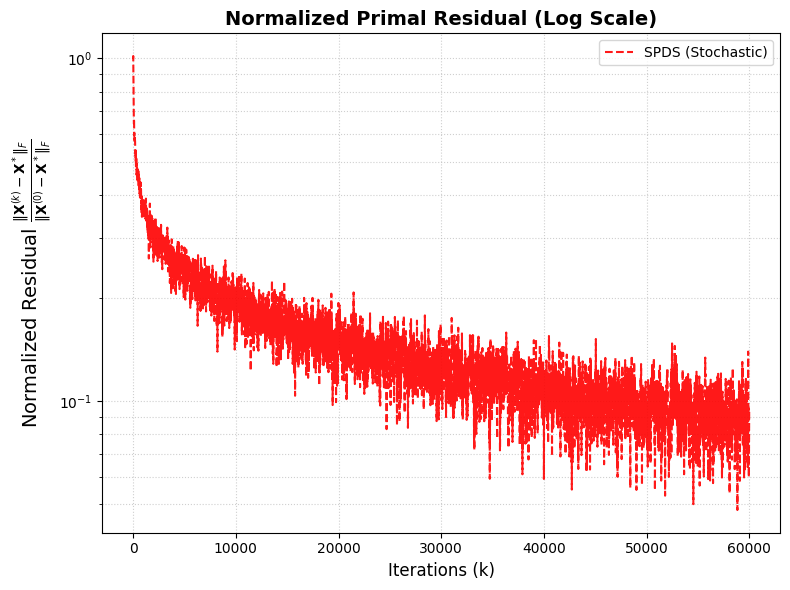

In [151]:
# --- D. VẼ BIỂU ĐỒ ---
plt.figure(figsize=(8, 6))
iterations = np.arange(len(residuals)) * LOG_FREQ

plt.semilogy(iterations, residuals,
             color='red', linestyle='--', linewidth=1.5, alpha=0.9,
             label='SPDS (Stochastic)')

plt.xlabel('Iterations (k)', fontsize=12)
plt.ylabel(r'Normalized Residual $\frac{\|\mathbf{X}^{(k)} - \mathbf{X}^*\|_F}{\|\mathbf{X}^{(0)} - \mathbf{X}^*\|_F}$', fontsize=14)
plt.title('Normalized Primal Residual (Log Scale)', fontsize=14, fontweight='bold')
plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()